# Fake News Detector

In [1]:
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from datasets import load_dataset
from datasets import Dataset, DatasetDict
from transformers import AutoConfig

import pandas as pd, numpy as np, torch, os, random, time, datetime, re

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

import warnings
warnings.filterwarnings('ignore')



c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define Models

In [136]:
model_bert_base_uncased ='bert-base-uncased'
model_distilbert_base_uncased ='distilbert-base-uncased'
model_mobilebert_base_uncased ='google/mobilebert-uncased'
model_tinybert_base_uncased ='mrm8488/bert-tiny-finetuned-sms-spam-detection'


model_list = ["model_bert_base_uncased", "model_distilbert_base_uncased", "model_mobilebert_base_uncased", "model_tinybert_base_uncased"]

# Define Tokenizer

In [ ]:
tokenizer_bert_base_uncased = AutoTokenizer.from_pretrained(model_bert_base_uncased)
tokenizer_distilbert_base_uncased = AutoTokenizer.from_pretrained(model_distilbert_base_uncased)
tokenizer_mobilebert_base_uncased = AutoTokenizer.from_pretrained(model_mobilebert_base_uncased)
tokenizer_tinybert_base_uncased = AutoTokenizer.from_pretrained(model_tinybert_base_uncased)





# Test Tokenizer

In [69]:
test_text = "Congratulations! You've won a free ticket to Bahamas. Call now to claim your prize."
toknizer_list =[tokenizer_bert_base_uncased, tokenizer_distilbert_base_uncased, tokenizer_mobilebert_base_uncased, tokenizer_tinybert_base_uncased]
toknizer_list_ref =["tokenizer_bert_base_uncased", "tokenizer_distilbert_base_uncased", "tokenizer_mobilebert_base_uncased", "tokenizer_tinybert_base_uncased"]

for tokenizer in toknizer_list:
    print("===============================================")
    print(tokenizer.name_or_path)
    print(tokenizer(test_text, return_tensors='pt'))



bert-base-uncased
{'input_ids': tensor([[  101, 23156,   999,  2017,  1005,  2310,  2180,  1037,  2489,  7281,
          2000, 17094,  1012,  2655,  2085,  2000,  4366,  2115,  3396,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
distilbert-base-uncased
{'input_ids': tensor([[  101, 23156,   999,  2017,  1005,  2310,  2180,  1037,  2489,  7281,
          2000, 17094,  1012,  2655,  2085,  2000,  4366,  2115,  3396,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
google/mobilebert-uncased
{'input_ids': tensor([[  101, 23156,   999,  2017,  1005,  2310,  2180,  1037,  2489,  7281,
          2000, 17094,  1012,  2655,  2085,  2000,  4366,  2115,  3396,  1012,
      

# Create the Tokenizer Function

In [173]:
def tokenize_function(examples, tokenizer):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)     

# Load data set

In [174]:
dataset= pd.read_csv(r"C:\Users\csc\Desktop\Kuntal_work\ktl_gen1\FineTune_DistillBert\WELFake_Dataset.csv", encoding='utf-8')
dataset.sample(5)

,Unnamed: 0,title,text,label
61370,61370,ARNOLD SCHWARZENEGGER Sends A Message To Liber...,,1
2189,2189,WOW! “We Mexicans Need To Kill Donald Trump Be...,And now a message of peace and unity from one ...,1
60609,60609,Jimmy Carter recovers from dehydration scare i...,"WINNIPEG, Manitoba (Reuters) - Former U.S. Pre...",0
51565,51565,2 Friars’ Mission: Reviving a Brooklyn Church ...,"The two Franciscan friars, complete with rob...",0
39431,39431,Boy With Autism Makes His First Friend Ever An...,Approximately 1 in 68 children has an autism s...,1


In [175]:
# checking the information of the dataset including memory usage

dataset.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 382.5 MB


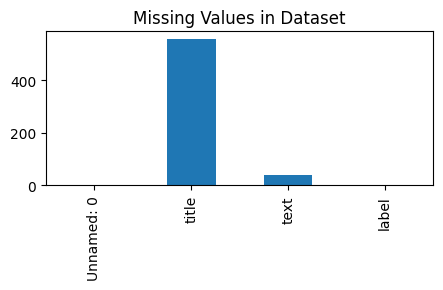

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [176]:
# Checking null values
import seaborn as sns
import matplotlib.pyplot as plt
dataset.isna().sum().plot(kind='bar', title='Missing Values in Dataset', figsize=(5,2))
plt.show()
dataset.isna().sum()

In [177]:
dataset[(dataset['title'].isna()==True) & (dataset['text'].isna()==True)]

,Unnamed: 0,title,text,label


In [178]:
# Imputing null values in the 'text' column with the corresponding values from the 'title' column
dataset['text'] = dataset['text'].combine_first(dataset['title'])


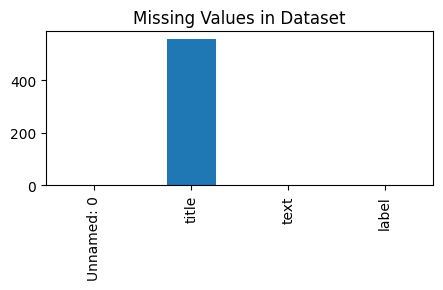

Unnamed: 0      0
title         558
text            0
label           0
dtype: int64

In [179]:
dataset.isna().sum().plot(kind='bar', title='Missing Values in Dataset', figsize=(5,2))
plt.show()
dataset.isna().sum()

label
1    0.514404
0    0.485596
Name: proportion, dtype: float64


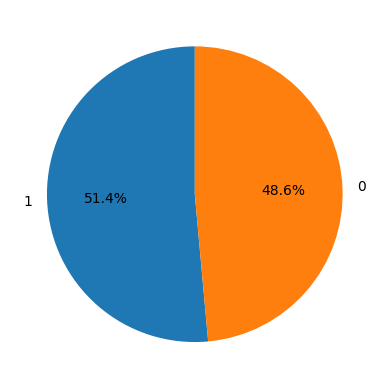

In [180]:
# Checking Data Imbalance 
lx=dataset['label'].value_counts(normalize=True)
print(lx)

plt.pie(lx, labels=lx.index, autopct='%1.1f%%', startangle=90)
plt.show()

In [181]:
# Keeping only required columns
dataset = dataset[['text', 'label']]
dataset["text"] = dataset["text"].apply(lambda x: re.sub(r"http\S+", "", str(x)))  # Remove URLs
dataset['text'] = dataset['text'].apply(lambda x: x.lower())  # Convert to lowercase
dataset['text_word_count']=dataset['text'].apply(lambda x: len(str(x).split()))  # Count words in text
dataset

,text,label,text_word_count
0,no comment is expected from barack obama membe...,1,871
1,did they post their votes for hillary already?,1,8
2,"now, most of the demonstrators gathered last ...",1,34
3,a dozen politically active pastors came here f...,0,1321
4,"the rs-28 sarmat missile, dubbed satan 2, will...",1,329
...,...,...,...
72129,washington (reuters) - hackers believed to be ...,0,735
72130,"you know, because in fantasyland republicans n...",1,604
72131,migrants refuse to leave train at refugee camp...,0,477
72132,mexico city (reuters) - donald trump’s combati...,0,559


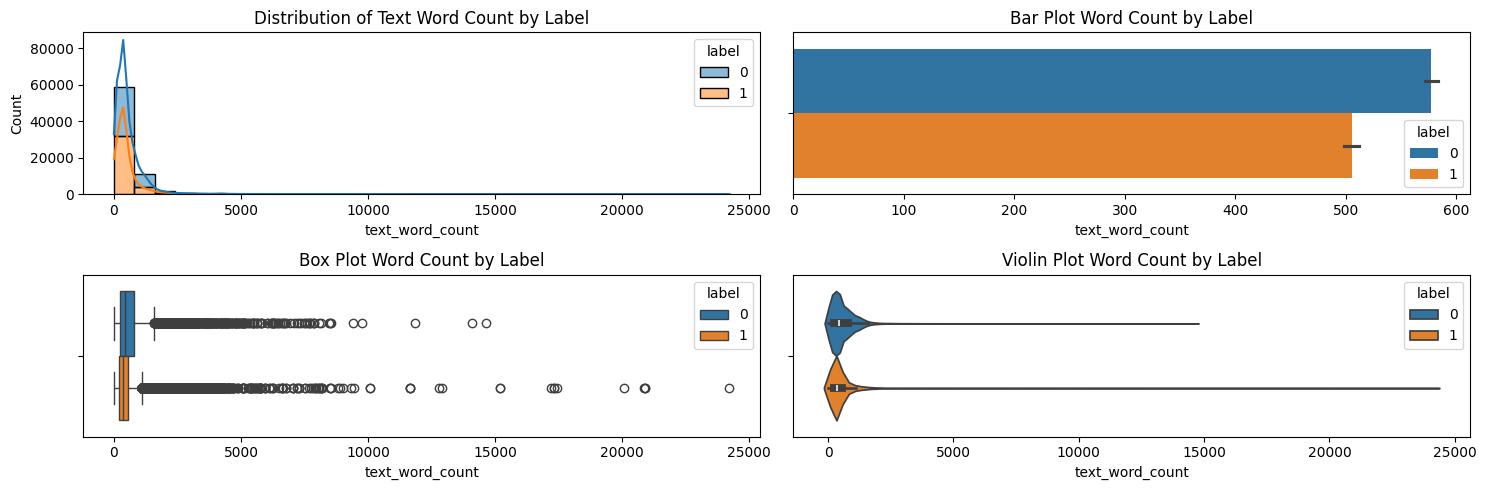

In [182]:
# Checking basics stats

fig, axs = plt.subplots(2,2 ,figsize=(15, 5))
sns.histplot(data=dataset, x='text_word_count', hue='label', multiple='stack', bins=30, kde=True, ax=axs[0,0])
axs[0,0].set_title('Distribution of Text Word Count by Label')

sns.barplot(data=dataset, x='text_word_count', hue='label',  ax=axs[0,1])
axs[0,1].set_title('Bar Plot Word Count by Label')

sns.boxplot(data=dataset, x='text_word_count', hue='label',  ax=axs[1,0])
axs[1,0].set_title('Box Plot Word Count by Label')


sns.violinplot(data=dataset, x='text_word_count', hue='label',  ax=axs[1,1])
axs[1,1].set_title('Violin Plot Word Count by Label')


plt.tight_layout()


In [183]:
# Spliting the dataset

train, test = train_test_split(dataset, test_size=0.4, random_state=42, stratify=dataset['label'])
test, val = train_test_split(test, test_size=0.3, random_state=42, stratify=test['label'])


train.shape, test.shape, val.shape, dataset.shape


((43280, 3), (20197, 3), (8657, 3), (72134, 3))

In [184]:
# Transforemer Consumable Dataset Creation

data_dict = DatasetDict({
    'train': Dataset.from_pandas(train, preserve_index=False).select(range(0, 100)),  # Select only the first 1000 rows for training
    'test': Dataset.from_pandas(test, preserve_index=False).select(range(0, 100)),  # Select only the first 1000 rows for testing
    'val': Dataset.from_pandas(val, preserve_index=False).select(range(0, 100))  # Select only the first 1000 rows for validation
})
data_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'text_word_count'],
        num_rows: 100
    })
    test: Dataset({
        features: ['text', 'label', 'text_word_count'],
        num_rows: 100
    })
    val: Dataset({
        features: ['text', 'label', 'text_word_count'],
        num_rows: 100
    })
})

In [185]:
# Check Tokenizer functuionality

for tokenizer in toknizer_list:
    print("===============================================")
    print(tokenizer.name_or_path)
    print(tokenize_function(data_dict['train'][10], tokenizer))
    print(f"Vocab size: {tokenizer.vocab_size}")

bert-base-uncased
{'input_ids': [101, 15976, 1006, 26665, 1007, 1011, 2148, 3088, 1055, 2523, 1997, 3067, 6198, 2545, 1998, 2810, 2586, 1006, 21962, 2226, 1007, 2056, 2006, 5095, 2178, 2266, 1997, 2049, 4105, 2018, 2042, 2915, 2757, 1010, 7781, 1011, 2806, 1010, 2023, 2051, 2012, 1037, 8840, 2078, 10020, 3079, 1011, 3067, 2006, 1996, 8899, 5583, 1999, 1996, 2225, 1997, 1996, 2406, 1012, 1037, 3026, 2880, 1997, 1996, 2586, 2001, 2915, 1998, 2730, 2648, 2019, 17727, 7911, 8899, 1006, 17727, 20051, 2015, 1007, 3067, 2048, 3134, 3283, 1010, 1998, 1996, 2586, 2056, 2274, 1997, 2049, 2372, 2018, 2042, 2730, 2144, 2251, 1012, 21962, 2226, 2343, 3312, 8785, 4609, 3501, 4213, 2056, 19842, 26741, 2072, 12170, 6672, 2721, 1010, 1037, 2740, 1998, 3808, 2961, 2012, 8840, 2078, 10020, 1055, 4687, 3683, 2361, 3067, 2379, 16266, 9126, 2050, 1999, 18399, 12059, 1010, 2001, 2915, 2006, 5958, 3944, 1999, 2392, 1997, 2010, 2564, 1998, 2416, 1011, 2095, 1011, 2214, 2684, 2096, 2027, 2020, 2006, 2037, 2126,

In [186]:
# Tokenizer Mapping 


def map_tokenizer(tokenizer):
    return data_dict.map(tokenize_function, fn_kwargs={'tokenizer': tokenizer}, batched=True, batch_size=32)


encoded_datasets = []
for tokenizer in toknizer_list:
    print("===============================================")
    print(tokenizer.name_or_path)
    name_x = f"{tokenizer.name_or_path.split('/')[-1].replace('-', '_')}_dataset"
    
    exec(f"tokenized_data_{name_x} = map_tokenizer(tokenizer)")
 
    print(f"tokenized_data_{name_x}")
    encoded_datasets.append(f"tokenized_data_{name_x}")


bert-base-uncased


Map: 100%|██████████| 100/100 [00:00<00:00, 1999.67 examples/s]


tokenized_data_bert_base_uncased_dataset
distilbert-base-uncased


Map: 100%|██████████| 100/100 [00:00<00:00, 3867.96 examples/s]


tokenized_data_distilbert_base_uncased_dataset
google/mobilebert-uncased


Map: 100%|██████████| 100/100 [00:00<00:00, 3741.24 examples/s]


tokenized_data_mobilebert_uncased_dataset
mrm8488/bert-tiny-finetuned-sms-spam-detection


Map: 100%|██████████| 100/100 [00:00<00:00, 6003.18 examples/s]

tokenized_data_bert_tiny_finetuned_sms_spam_detection_dataset


In [187]:
# We can see the name letter
encoded_datasets

['tokenized_data_bert_base_uncased_dataset',
 'tokenized_data_distilbert_base_uncased_dataset',
 'tokenized_data_mobilebert_uncased_dataset',
 'tokenized_data_bert_tiny_finetuned_sms_spam_detection_dataset']

# Model Building

In [188]:
# Make id2level and level2id mapping for the labels

level2id = {'real':1, 'fake':0}
print(level2id)

id2level = {v: k for k, v in level2id.items()}
print(id2level)

num_labels = len(level2id)
print(f"Number of labels: {num_labels}")

{'real': 1, 'fake': 0}
{1: 'real', 0: 'fake'}
Number of labels: 2


In [189]:
# Define the device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [190]:
model_list

['model_bert_base_uncased',
 'model_distilbert_base_uncased',
 'model_mobilebert_base_uncased',
 'model_tinybert_base_uncased']

In [191]:
# Make the model configarations

config_bert_base_uncased = AutoConfig.from_pretrained(model_bert_base_uncased, label2id=level2id, id2label=id2level, num_labels=num_labels)
config_distilbert_base_uncased = AutoConfig.from_pretrained(model_distilbert_base_uncased, label2id=level2id, id2label=id2level, num_labels=num_labels)
config_mobilebert_base_uncased = AutoConfig.from_pretrained(model_mobilebert_base_uncased, label2id=level2id, id2label=id2level, num_labels=num_labels)
config_tinybert_base_uncased = AutoConfig.from_pretrained(model_tinybert_base_uncased, label2id=level2id, id2label=id2level, num_labels=num_labels)

In [192]:
# Create the models

model_bert_base_uncased_auto = AutoModelForSequenceClassification.from_pretrained(model_bert_base_uncased, config=config_bert_base_uncased).to(device)


model_distillbert_base_uncased_auto = AutoModelForSequenceClassification.from_pretrained(model_distilbert_base_uncased, config=config_distilbert_base_uncased).to(device)


model_mobilebert_base_uncased_auto = AutoModelForSequenceClassification.from_pretrained(model_mobilebert_base_uncased, config=config_mobilebert_base_uncased).to(device)


model_tinybert_base_uncased_auto = AutoModelForSequenceClassification.from_pretrained(model_tinybert_base_uncased, config=config_tinybert_base_uncased).to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5923.61it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

# Create the Evaluation Metric

In [193]:
def evaluate_model(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision = precision_score(labels, preds, average='binary')
    recall = recall_score(labels, preds, average='binary')
    accuracy = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='binary')
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}
   

# Create The Training Argumnets

In [194]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

In [195]:
batch_size = 32
training_dir = "./results"
callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]

def CreateTrainer(model, tokenized_datasets):
    training_args =TrainingArguments(
        output_dir=training_dir+f"{model.name_or_path.split('/')[-1].replace('-', '_')}",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=2e-5,
        weight_decay=0.01,
        num_train_epochs=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        eval_strategy="epoch",
        save_strategy="epoch",
        
    )

   

    print(f"Output directory: {training_args.output_dir}")




    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["val"],
        callbacks=callbacks,
        compute_metrics=evaluate_model

    )
    return trainer

In [196]:
# Dynamic Trainer Creation
trainer_list =[f"trainer_{i}" for i in model_list]
trainer_list

['trainer_model_bert_base_uncased',
 'trainer_model_distilbert_base_uncased',
 'trainer_model_mobilebert_base_uncased',
 'trainer_model_tinybert_base_uncased']

# Make the Trainers

In [218]:
trainers={}

models_and_data = {
    "bert": (model_bert_base_uncased_auto, tokenized_data_bert_base_uncased_dataset),
    "distilbert": (model_distillbert_base_uncased_auto, tokenized_data_distilbert_base_uncased_dataset),
    "mobilebert": (model_mobilebert_base_uncased_auto, tokenized_data_mobilebert_uncased_dataset),
    "tinybert": (model_tinybert_base_uncased_auto, tokenized_data_bert_tiny_finetuned_sms_spam_detection_dataset),
}


tokenizers_map = {
    "bert": tokenizer_bert_base_uncased,
    "distilbert": tokenizer_distilbert_base_uncased,
    "mobilebert": tokenizer_mobilebert_base_uncased,
    "tinybert": tokenizer_tinybert_base_uncased,
}



for name, (model, dataset) in models_and_data.items():
    print(f"Creating trainer for {name}...")
    trainers[name] = CreateTrainer(model, dataset)


Creating trainer for bert...
Output directory: ./resultsbert_base_uncased
Creating trainer for distilbert...
Output directory: ./resultsdistilbert_base_uncased
Creating trainer for mobilebert...
Output directory: ./resultsmobilebert_uncased
Creating trainer for tinybert...
Output directory: ./resultsbert_tiny_finetuned_sms_spam_detection


In [198]:
trainers

{'bert': <transformers.trainer.Trainer at 0x1a3bfd13530>,
 'distilbert': <transformers.trainer.Trainer at 0x1a3bfd11160>,
 'mobilebert': <transformers.trainer.Trainer at 0x1a3bfd10170>,
 'tinybert': <transformers.trainer.Trainer at 0x1a3bfd11ee0>}

# Train the models

In [199]:
import time

In [ ]:
for name, trainer in trainers.items():
    start_time = time.time()
    print(f"Training started at: {time.strftime('%H:%M:%S')}")
    print(f"\n{'='*50}")
    print(f"Training model: {name}")
    print(f"{'='*50}")
    trainer.train()

    trainer.save_model(f"./saved_models/{name}_finetuned")
    tokenizers_map.save_model(f"./saved_models/{name}_finetuned")
    end_time = time.time()
    print(f"Training ended at: {time.strftime('%H:%M:%S')}")
    print(f"Total time taken by {name} : {end_time - start_time:.2f} seconds")
    print(f"Total time taken by {name}: {(end_time - start_time)/60:.2f} minutes")


Training started at: 00:09:46

Training model: bert


c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.615856,0.750000,0.693333,0.962963,0.806202


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.16it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training ended at: 00:13:05
Total time taken by bert : 199.03 seconds
Total time taken by bert: 3.32 minutes
Training started at: 00:13:05

Training model: distilbert


...

Training ended at: 00:15:06
Total time taken by mobilebert : 72.82 seconds
Total time taken by mobilebert: 1.21 minutes
Training started at: 00:15:06

Training model: tinybert


c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.930888,0.470000,0.529412,0.166667,0.253521


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 111.11it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.bet

Training ended at: 00:15:09
Total time taken by tinybert : 3.42 seconds
Total time taken by tinybert: 0.06 minutes


In [201]:
# Check one evaluation
trainers['bert'].callback_handler.callbacks = []   # temporarily remove the callbacks 
metrics = trainers['bert'].evaluate()
print(metrics)

c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.6158562302589417, 'eval_accuracy': 0.75, 'eval_precision': 0.6933333333333334, 'eval_recall': 0.9629629629629629, 'eval_f1': 0.8062015503875969, 'eval_runtime': 11.2993, 'eval_samples_per_second': 8.85, 'eval_steps_per_second': 0.354, 'epoch': 1.0}


In [203]:
trainers

{'bert': <transformers.trainer.Trainer at 0x1a3bfd13530>,
 'distilbert': <transformers.trainer.Trainer at 0x1a3bfd11160>,
 'mobilebert': <transformers.trainer.Trainer at 0x1a3bfd10170>,
 'tinybert': <transformers.trainer.Trainer at 0x1a3bfd11ee0>}

In [207]:
encoded_datasets

['tokenized_data_bert_base_uncased_dataset',
 'tokenized_data_distilbert_base_uncased_dataset',
 'tokenized_data_mobilebert_uncased_dataset',
 'tokenized_data_bert_tiny_finetuned_sms_spam_detection_dataset']

In [210]:
# Prediction

y_formed_bert = trainers['bert'].predict(tokenized_data_bert_base_uncased_dataset['test'])
y_formed_distillbert = trainers['distilbert'].predict(tokenized_data_distilbert_base_uncased_dataset['test'])
y_formed_mobilebert = trainers['mobilebert'].predict(tokenized_data_mobilebert_uncased_dataset['test'])
y_formed_bert_tiny = trainers['tinybert'].predict(tokenized_data_bert_tiny_finetuned_sms_spam_detection_dataset['test'])

c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [211]:
y_pred_bert=y_formed_bert.predictions.argmax(-1)
y_pred_distillbert=y_formed_distillbert.predictions.argmax(-1)
y_pred_mobilebert=y_formed_mobilebert.predictions.argmax(-1)
y_pred_bert_tiny=y_formed_bert_tiny.predictions.argmax(-1)

In [237]:
# Check Against the diffrent models 
def evaluate_predictions(y_formed, y_pred, model_name):
    print(f"Evaluation Metrics for {model_name}:")
    print("=" * 50)
    accuracy = accuracy_score(y_formed.label_ids, y_pred)
    pre = precision_score(y_formed.label_ids, y_pred)
    recall = recall_score(y_formed.label_ids, y_pred)
    f1 = f1_score(y_formed.label_ids, y_pred)
    print("Classfication report")
    print(classification_report(y_formed.label_ids, y_pred))
    x=confusion_matrix(y_formed.label_ids, y_pred)
    sns.heatmap(x, cmap='Reds', xticklabels=level2id.keys(), yticklabels=level2id.keys(), annot=True, fmt='.2f')


    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")


# Normal Bert

Evaluation Metrics for bert:
Classfication report
              precision    recall  f1-score   support

           0       0.96      0.52      0.68        48
           1       0.69      0.98      0.81        52

    accuracy                           0.76       100
   macro avg       0.83      0.75      0.74       100
weighted avg       0.82      0.76      0.75       100

Accuracy: 0.7600
Precision: 0.6892
Recall: 0.9808
F1 Score: 0.8095


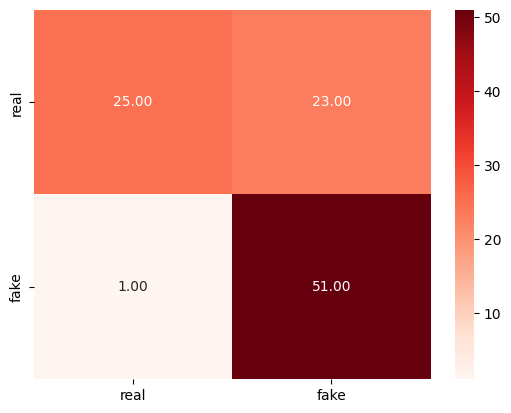

In [238]:
evaluate_predictions(y_formed_bert, y_pred_bert, 'bert')

# Distill Bert

Evaluation Metrics for distil_bert:
Classfication report
              precision    recall  f1-score   support

           0       0.79      0.23      0.35        48
           1       0.57      0.94      0.71        52

    accuracy                           0.60       100
   macro avg       0.68      0.59      0.53       100
weighted avg       0.67      0.60      0.54       100

Accuracy: 0.6000
Precision: 0.5698
Recall: 0.9423
F1 Score: 0.7101


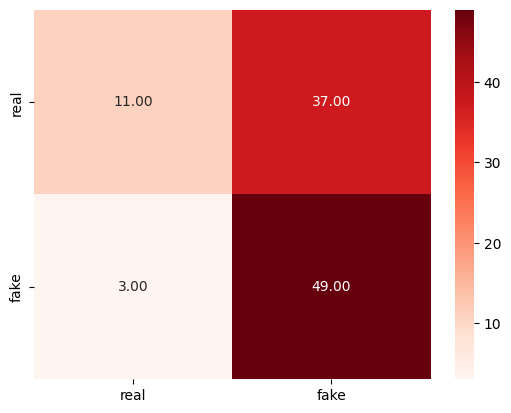

In [239]:
evaluate_predictions(y_formed_distillbert, y_pred_distillbert, 'distil_bert')

# Mobile Bert

Evaluation Metrics for Mobile Bert:
Classfication report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        48
           1       0.52      1.00      0.68        52

    accuracy                           0.52       100
   macro avg       0.26      0.50      0.34       100
weighted avg       0.27      0.52      0.36       100

Accuracy: 0.5200
Precision: 0.5200
Recall: 1.0000
F1 Score: 0.6842


c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\csc\Desktop\Kuntal_work\ktl_gen1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

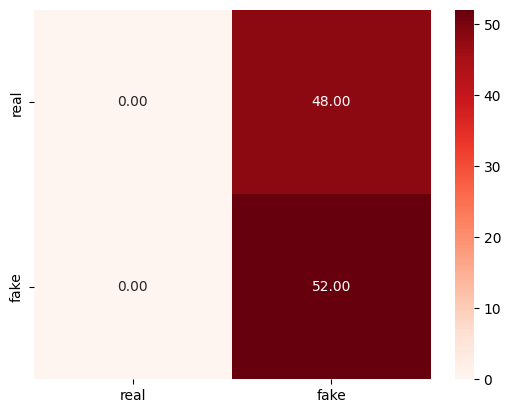

In [240]:
evaluate_predictions(y_formed_mobilebert, y_pred_mobilebert, "Mobile Bert")

# Tiny Bert

Evaluation Metrics for tiny-bert:
Classfication report
              precision    recall  f1-score   support

           0       0.52      0.85      0.65        48
           1       0.67      0.27      0.38        52

    accuracy                           0.55       100
   macro avg       0.59      0.56      0.51       100
weighted avg       0.60      0.55      0.51       100

Accuracy: 0.5500
Precision: 0.6667
Recall: 0.2692
F1 Score: 0.3836


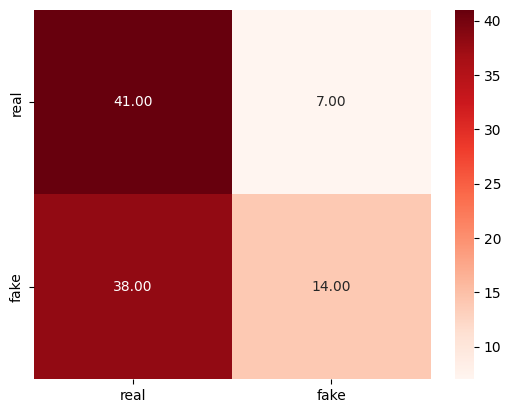

In [241]:
evaluate_predictions(y_formed_bert_tiny, y_pred_bert_tiny, "tiny-bert")